   moisture  temperature  humidity  light    ph  air_quality  nutrient  \
0       198           22        20    428  4.61          589        74   
1       330           20        86    537  4.75          752        77   
2       117           25        55    681  4.90          610        38   
3       183           24        71    450  4.91          578        35   
4       206           19        43    602  7.07          661        38   

          label  
0        stress  
1        stress  
2  water_needed  
3        stress  
4       healthy  
Accuracy: 0.6833333333333333


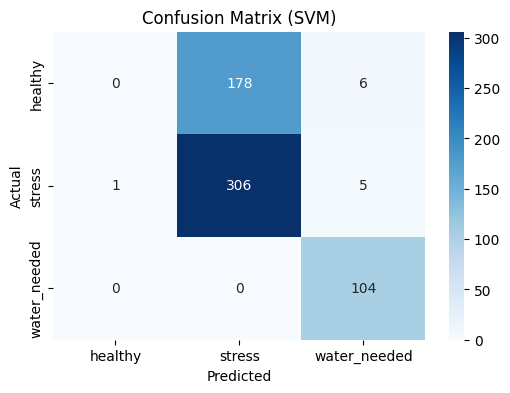

Plant condition: stress


In [1]:
# Jupyter notebook me graph show karne ke liye
%matplotlib inline

# Imports
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Load dataset
data = pd.read_csv("plant_data_7params_3000.csv")
print(data.head())

# 2️⃣ Features and label
X = data[['moisture','temperature','humidity','light','ph','air_quality','nutrient']]
y = data['label']

# 3️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4️⃣ Model create & train
model = SVC(kernel='rbf')  # radial basis function kernel
model.fit(X_train, y_train)

# 5️⃣ Test model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# 6️⃣ Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (SVM)")
plt.show()

# 7️⃣ Manual prediction example
new_data = pd.DataFrame(
    [[200, 30, 50, 500, 6.5, 400, 60]],
    columns=['moisture','temperature','humidity','light','ph','air_quality','nutrient']
)

prediction = model.predict(new_data)
print("Plant condition:", prediction[0])